<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/ml_python.png' width=600/></center>

<img src = "https://github.com/Jangrae/img/blob/master/mobile2.png?raw=true" width=800 align="left"/>

# 실습 내용

- 여러 알고리즘으로 만든 모델의 성능을 교차 검증을 통해 예측해 봅니다.
- 성능이 좋을 것으로 예상되는 알고리즘으로 최적화된 성능의 모델을 만듭니다.
- 튜닝된 모델의 성능을 평가합니다.

# 1.환경 준비

- 기본 라이브러리와 대상 데이터를 가져와 이후 과정을 준비합니다.

In [3]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

In [26]:
# 데이터 불러오기
path = 'https://raw.githubusercontent.com/jangrae/csv/master/mobile_cust_churn.csv'
data = pd.read_csv(path)
data['CHURN'] = data['CHURN'].map({'STAY':0, 'LEAVE': 1})  # 0과 1로 바꾼 이유: sklearn에서만 문자가 가능하고, XGBoost에서는 숫자만 가능하기 때문에 바꿔준 것이다.

# 2.데이터 이해

- 분석할 데이터를 충분히 이해할 수 있도록 다양한 탐색 과정을 수행합니다.

**데이터 설명**

- COLLEGE: 대학 졸업여부
- INCOME: 연수입
- OVERAGE: 월평균 초과사용 시간(분)
- LEFTOVER: 월평균 잔여시간비율(%)
- HOUSE: 집값
- HANDSET_PRICE: 스마트폰 가격
- OVER_15MINS_CALLS_PER_MONTH: 월평균 장기통화(15분이상) 횟수
- AVERAGE_CALL_DURATION: 평균 통화 시간
- REPORTED_SATISFACTION: 만족도 설문조사 결과
- REPORTED_USAGE_LEVEL: 사용도 자가진단 결과
- CONSIDERING_CHANGE_OF_PLAN: 향후 변경계획 설문조사 결과
- **CHURN: 이탈(번호이동) 여부**

In [7]:
# 데이터 살펴보기
data.head()

,id,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION,REPORTED_USAGE_LEVEL,CONSIDERING_CHANGE_OF_PLAN,CHURN
0,1,0,31953,0,6,313378,161,0,4,unsat,little,no,0
1,2,1,36147,0,13,800586,244,0,6,unsat,little,considering,0
2,3,1,27273,230,0,305049,201,16,15,unsat,very_little,perhaps,0
3,4,0,120070,38,33,788235,780,3,2,unsat,very_high,considering,1
4,5,1,29215,208,85,224784,241,21,1,very_unsat,little,never_thought,0


In [9]:
# 기술통계 확인
data.describe()

,id,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,CHURN
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,0.502400,80281.447750,85.979550,23.898650,493155.264250,389.615100,8.000700,6.002250,0.492600
std,5773.647028,0.500007,41680.586319,85.992324,26.816645,252407.884692,213.820682,8.925418,4.402558,0.499958
min,1.000000,0.000000,20007.000000,-2.000000,0.000000,150002.000000,130.000000,0.000000,1.000000,0.000000
25%,5000.750000,0.000000,42217.000000,0.000000,0.000000,263714.250000,219.000000,1.000000,2.000000,0.000000
50%,10000.500000,1.000000,75366.500000,59.000000,14.000000,452259.500000,326.000000,4.000000,5.000000,0.000000
75%,15000.250000,1.000000,115881.750000,179.000000,41.000000,702378.000000,533.250000,15.000000,10.000000,1.000000
max,20000.000000,1.000000,159983.000000,335.000000,89.000000,999996.000000,899.000000,29.000000,15.000000,1.000000


In [11]:
# 변수 관련 정보 확인
data.info()

# REPORTED_SATISFACTION, REPORTED_USAGE_LEVEL, CONSIDERING_CHANGE_OF_PLAN  -> object변수

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           20000 non-null  int64 
 1   COLLEGE                      20000 non-null  int64 
 2   INCOME                       20000 non-null  int64 
 3   OVERAGE                      20000 non-null  int64 
 4   LEFTOVER                     20000 non-null  int64 
 5   HOUSE                        20000 non-null  int64 
 6   HANDSET_PRICE                20000 non-null  int64 
 7   OVER_15MINS_CALLS_PER_MONTH  20000 non-null  int64 
 8   AVERAGE_CALL_DURATION        20000 non-null  int64 
 9   REPORTED_SATISFACTION        20000 non-null  object
 10  REPORTED_USAGE_LEVEL         20000 non-null  object
 11  CONSIDERING_CHANGE_OF_PLAN   20000 non-null  object
 12  CHURN                        20000 non-null  int64 
dtypes: int64(10), object(3)
memory 

# 3.데이터 준비

- 전처리 과정을 통해 머신러닝 알고리즘에 사용할 수 있는 형태의 데이터를 준비합니다.

**1) 변수 제거**

In [28]:
# 변수 제거: id
drop_col = 'id'
data.drop(columns = drop_col, axis = 1, inplace = True)

# 확인
data.head(3)

,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION,REPORTED_USAGE_LEVEL,CONSIDERING_CHANGE_OF_PLAN,CHURN
0,0,31953,0,6,313378,161,0,4,unsat,little,no,0
1,1,36147,0,13,800586,244,0,6,unsat,little,considering,0
2,1,27273,230,0,305049,201,16,15,unsat,very_little,perhaps,0


**2) x, y 분리**

In [31]:
# x, y 분리
target = 'CHURN'

x = data.drop(columns = target)
y = data.loc[:,target]

x.head(3)

,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION,REPORTED_USAGE_LEVEL,CONSIDERING_CHANGE_OF_PLAN
0,0,31953,0,6,313378,161,0,4,unsat,little,no
1,1,36147,0,13,800586,244,0,6,unsat,little,considering
2,1,27273,230,0,305049,201,16,15,unsat,very_little,perhaps


**3) 가변수화**

In [33]:
# 가변수화
dum_cols = ['REPORTED_SATISFACTION', 'REPORTED_USAGE_LEVEL', 'CONSIDERING_CHANGE_OF_PLAN']

x = pd.get_dummies(x, columns = dum_cols, drop_first = True, dtype = int)

# 확인
x.head()

,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION_sat,REPORTED_SATISFACTION_unsat,REPORTED_SATISFACTION_very_sat,REPORTED_SATISFACTION_very_unsat,REPORTED_USAGE_LEVEL_high,REPORTED_USAGE_LEVEL_little,REPORTED_USAGE_LEVEL_very_high,REPORTED_USAGE_LEVEL_very_little,CONSIDERING_CHANGE_OF_PLAN_considering,CONSIDERING_CHANGE_OF_PLAN_never_thought,CONSIDERING_CHANGE_OF_PLAN_no,CONSIDERING_CHANGE_OF_PLAN_perhaps
0,0,31953,0,6,313378,161,0,4,0,1,0,0,0,1,0,0,0,0,1,0
1,1,36147,0,13,800586,244,0,6,0,1,0,0,0,1,0,0,1,0,0,0
2,1,27273,230,0,305049,201,16,15,0,1,0,0,0,0,0,1,0,0,0,1
3,0,120070,38,33,788235,780,3,2,0,1,0,0,0,0,1,0,1,0,0,0
4,1,29215,208,85,224784,241,21,1,0,0,0,1,0,1,0,0,0,1,0,0


**4) 학습용, 평가용 데이터 분리**

In [35]:
# 학습용, 평가용 데이터 분리
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

**5) 정규화**

In [40]:
# 정규화
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

# 4.성능 예측

- 여러 알고리즘으로 만든 모델의 성능을 교차 검증을 통해 예측해 봅니다.
- 하이퍼파라미터를 설정하지 않고 진행합니다.
- 예측된 성능 정보를 수집해 마지막에 비교합니다.

In [ ]:
# xgboost 설치
# !pip install xgboost

In [ ]:
# lightgbm 설치
# !pip install lightgbm

- 이후 사용할 함수를 모두 불러옵니다.

In [56]:
# 불러오기

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import cross_val_score

**1) KNN**

- KNN 모델의 성능을 교차 검증을 통해 예측해 봅니다.

In [59]:
# 성능예측
model = KNeighborsClassifier()

cv_score = cross_val_score(model, x_train_s, y_train, cv = 5, scoring='accuracy')

# 확인
print(cv_score.mean())

0.5930000000000001


In [61]:
# 결과수집
result = {}
result['KNN'] = cv_score.mean()

**2) Decision Tree**

- Decision Tree 모델의 성능을 교차 검증을 통해 예측해 봅니다.

In [66]:
# 성능예측
model = DecisionTreeClassifier(max_depth = 5)

cv_score = cross_val_score(model, x_train, y_train, cv = 5)

# 확인 
print(cv_score.mean())

0.6962142857142857


In [68]:
# 결과수집
result['Decision Tree'] = cv_score.mean()

**3) Logistic Regression**

- Logistic Regression 모델의 성능을 교차 검증을 통해 예측해 봅니다.

In [70]:
# 성능예측
model = LogisticRegression()

cv_score = cross_val_score(model, x_train, y_train, cv=5)

# 확인
print(cv_score.mean())

0.6350714285714286


In [72]:
# 결과수집
result['Logistic Regression'] = cv_score.mean()

**4) Random Forest**

- Random Forest 모델의 성능을 교차 검증을 통해 예측해 봅니다.

In [74]:
# 성능예측
model = RandomForestClassifier(max_depth=5)

cv_score = cross_val_score(model, x_train, y_train, cv=5)

print(cv_score.mean())

0.6952857142857144


In [76]:
# 결과수집
result['Random Forest'] = cv_score.mean()

**5) XGBoost**

- XGBoost 모델의 성능을 교차 검증을 통해 예측해 봅니다.

In [80]:
# 성능예측
model = XGBClassifier(max_depth=5)

cv_score = cross_val_score(model, x_train, y_train, cv=5)

print(cv_score.mean())

0.6914285714285715


In [82]:
# 결과수집
result['XGBoost'] = cv_score.mean()

**6) LightGBM**

- LightGBM 모델의 성능을 교차 검증을 통해 예측해 봅니다.

In [86]:
# 성능예측
model = LGBMClassifier(max_depth=5, verbose=-1, importance_type = 'split')   # importance_type = 'split', 'gain'

cv_score = cross_val_score(model, x_train, y_train, cv=5)

print(cv_score.mean())

0.6958571428571428


In [88]:
# 결과수집
result['LightGBM'] = cv_score.mean()

# 5.결과 확인

- 예측된 각 모델의 성능을 비교합니다.

In [98]:
# 성능 비교

result

{'KNN': 0.5930000000000001,
 'Decision Tree': 0.6962142857142857,
 'Logistic Regression': 0.6350714285714286,
 'Random Forest': 0.6952857142857144,
 'XGBoost': 0.6914285714285715,
 'LightGBM': 0.6958571428571428}

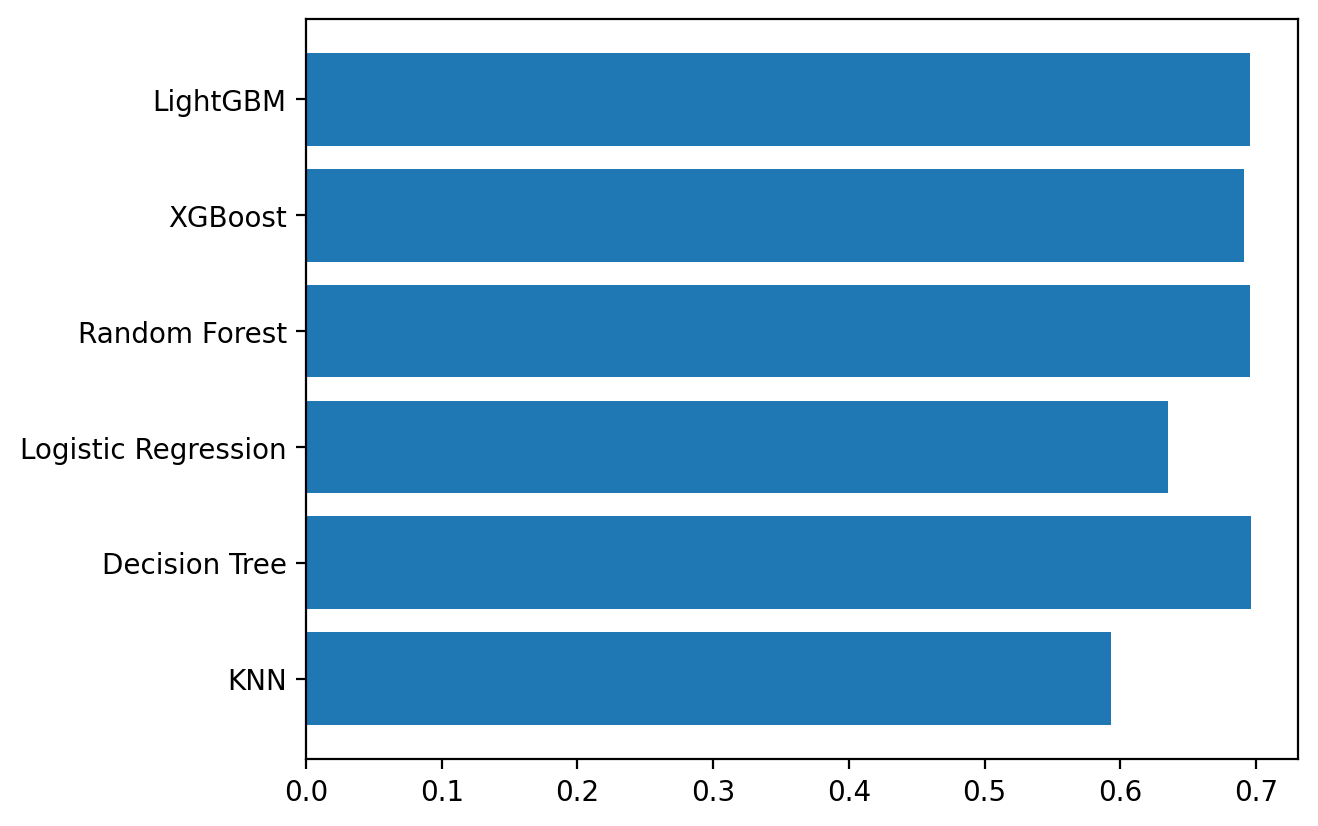

In [101]:
# 성능 시각화 비교

plt.barh(list(result.keys()), result.values())
plt.show()

# 6.성능 튜닝

- 위에서 성능이 가장 좋을 것으로 예측된 알고리즘으로 모델링합니다.
- 본 실습에서는 하이퍼파라미터가 최적화된 LightGBM 모델을 만듭니다.

In [135]:
# 불러오기
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import *

In [149]:
# 파라미터 
param = {'max_depth': range(1, 21),
         'n_estimators': range(60, 131, 10)}

# 모델 선언
model = GridSearchCV(LGBMClassifier(verbose =-1),
                     param,
                     cv=5)


# model = GridSearchCV(LGBMClassifier(random_state=1),    # 기본 모델
#                            param,                             # 파라미터 범위
#                            cv = 5,                            # k분할 개수    # default가 5이다.   # 내부에서 cross validation이 돌아가고 있다.
#                            scoring = 'r2'                     # 사용할 평가 지표
#                           )

In [151]:
# 학습하기(많은 시간이 소요될 수 있음)

model.fit(x_train, y_train)     # 최선의 하이퍼파라미터를 가지고 있다.

GridSearchCV(cv=5, estimator=LGBMClassifier(verbose=-1),
             param_grid={'max_depth': range(1, 21),
                         'n_estimators': range(60, 131, 10)})

In [152]:
# 예측하기
y_pred = model.predict(x_test)

In [153]:
# 성능평가
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1928 1137]
 [ 673 2262]]
              precision    recall  f1-score   support

           0       0.74      0.63      0.68      3065
           1       0.67      0.77      0.71      2935

    accuracy                           0.70      6000
   macro avg       0.70      0.70      0.70      6000
weighted avg       0.70      0.70      0.70      6000



In [159]:
# 최적 파라미터, 예측 최고 성능

# 중요 정보 확인
print('=' * 80)
print(model.cv_results_['mean_test_score'])  # 위에서 cv를 5로 진행했었던것의 평균값 출력
print('-' * 80)
print('최적파라미터:', model.best_params_)
print('-' * 80)
print('최고성능:', model.best_score_)
print('=' * 80)


[0.67657143 0.67807143 0.677      0.67635714 0.67542857 0.67242857
 0.67192857 0.67178571 0.68621429 0.68935714 0.69057143 0.6925
 0.69257143 0.69464286 0.69592857 0.69621429 0.69528571 0.69571429
 0.69478571 0.6955     0.69528571 0.6945     0.69428571 0.69528571
 0.6995     0.69835714 0.69821429 0.69757143 0.6955     0.69721429
 0.69592857 0.69607143 0.69592857 0.69778571 0.69764286 0.69671429
 0.69585714 0.69307143 0.69342857 0.69371429 0.69692857 0.69757143
 0.698      0.69907143 0.698      0.69721429 0.69535714 0.6955
 0.69578571 0.69464286 0.69507143 0.69621429 0.69635714 0.69585714
 0.69735714 0.69835714 0.6945     0.69514286 0.69442857 0.69664286
 0.69664286 0.69728571 0.69642857 0.69692857 0.69864286 0.69835714
 0.69942857 0.69764286 0.69671429 0.6955     0.69542857 0.69542857
 0.69607143 0.69535714 0.69514286 0.69657143 0.69635714 0.69728571
 0.6965     0.69442857 0.69607143 0.69735714 0.697      0.69714286
 0.69621429 0.694      0.69378571 0.69457143 0.69721429 0.69514286
 0.

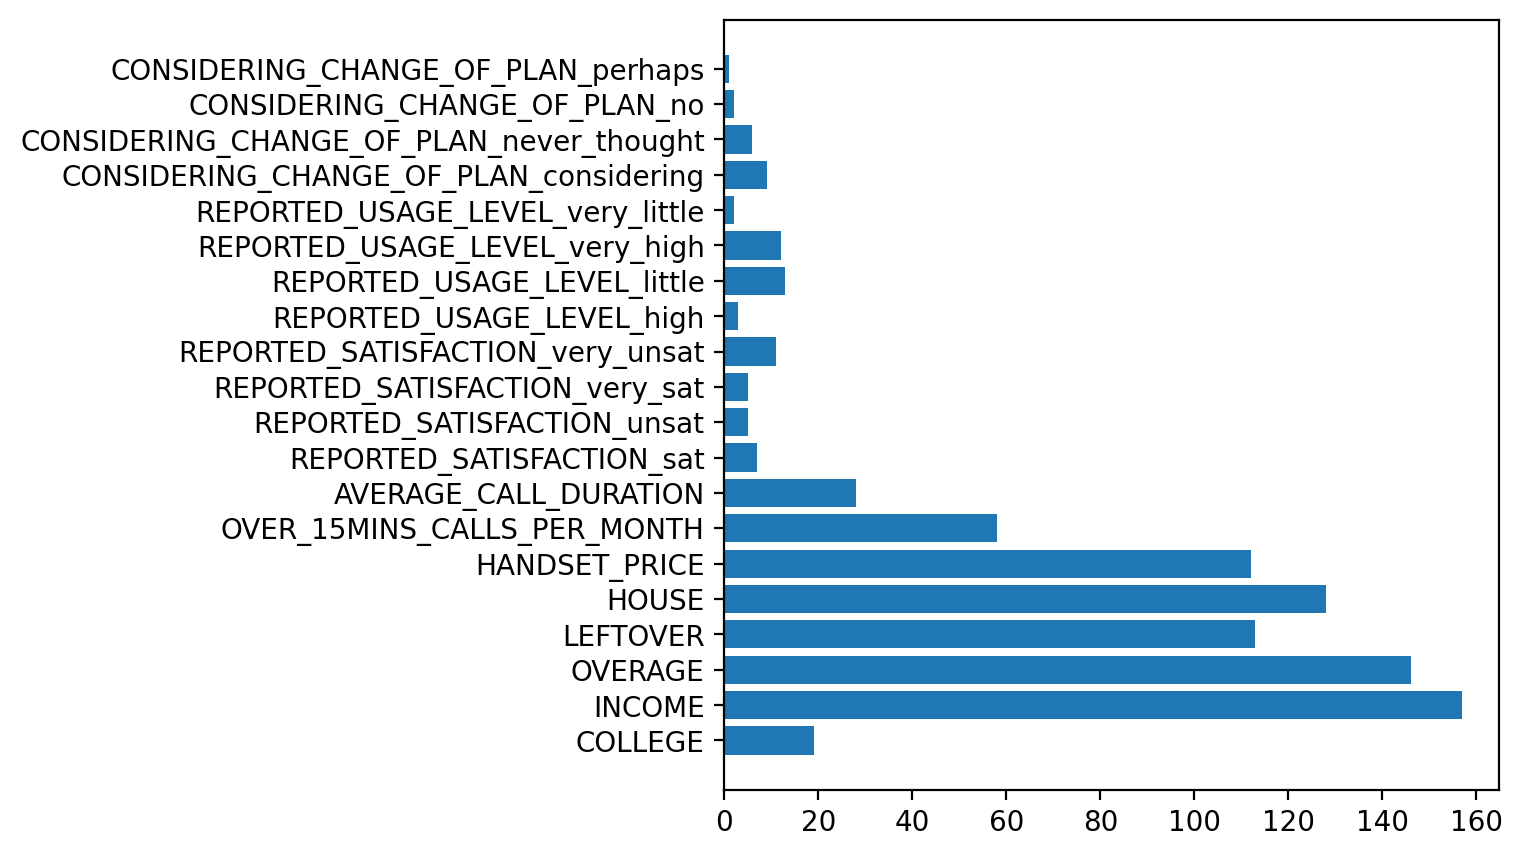

In [161]:
# 변수 중요도 시각화
plt.figure(figsize=(5, 5))
plt.barh(y=list(x), width=model.best_estimator_.feature_importances_)
plt.show()

# 7.성능 평가

- 최적 파라미터로 학습된 모델에 대해 최종 성능 평가를 진행합니다.

In [163]:
# 예측하기
y_pred = model.predict(x_test)

In [165]:
# 성능평가
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1928 1137]
 [ 673 2262]]
              precision    recall  f1-score   support

           0       0.74      0.63      0.68      3065
           1       0.67      0.77      0.71      2935

    accuracy                           0.70      6000
   macro avg       0.70      0.70      0.70      6000
weighted avg       0.70      0.70      0.70      6000

